# ДЗ 6

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

plt.rcParams["figure.figsize"] = (8, 6)


# Задача 1.

Неявная схема Эйлера будет иметь вид:
$$u_{n+1} = u_n + \tau\,\lambda u_{n+1} \quad\Rightarrow\quad u_{n+1} = \frac{u_n}{1 - \tau\lambda}.$$

In [159]:
def euler_solve(lam, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    for k in range(num_steps):
        y[k + 1] = y[k] + dt * lam * y[k]
    return tt, y


def implicit_euler_solve(lam, u0, T, dt):
    """Решает du/dt = lambda u на 0 < t < T с u(t=0) = u0 при помощи неявного метода Эйлера."""
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    denom = 1.0 - dt * lam
    for k in range(num_steps):
        y[k + 1] = y[k] / denom
    return tt, y


In [160]:
lam = -0.5
T_end = 5 / abs(lam)
moderate = []
for dt in (0.1 / abs(lam), 0.5 / abs(lam), 1.5 / abs(lam)):
    tt, y_exp = euler_solve(lam, 1.0, T_end, dt)
    tt_i, y_imp = implicit_euler_solve(lam, 1.0, T_end, dt)
    moderate.append((dt, tt, y_exp, tt_i, y_imp))
tt_f_moderate = np.linspace(0, T_end, 300)


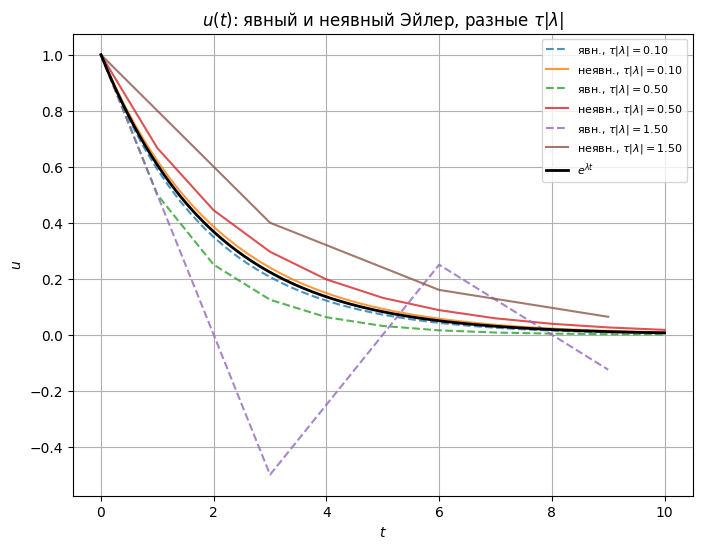

In [161]:
fig, ax = plt.subplots()
for dt, tt, y_exp, tt_i, y_imp in moderate:
    ax.plot(tt, y_exp, "--", alpha=0.8, label=rf"явн., $\tau|\lambda|={abs(lam)*dt:.2f}$")
    ax.plot(tt_i, y_imp, "-", alpha=0.8, label=rf"неявн., $\tau|\lambda|={abs(lam)*dt:.2f}$")
ax.plot(tt_f_moderate, np.exp(lam * tt_f_moderate), "k-", lw=2, label=r"$e^{\lambda t}$")
ax.set_title(r"$u(t)$: явный и неявный Эйлер, разные $\tau|\lambda|$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.legend(fontsize=8, loc="best")
ax.grid()
plt.show()


In [162]:
T_big = 8 / abs(lam)
dt_big = 2.1 / abs(lam)
tt_b, y_exp_b = euler_solve(lam, 1.0, T_big, dt_big)
tt_i_b, y_imp_b = implicit_euler_solve(lam, 1.0, T_big, dt_big)
tt_f_big = np.linspace(0, T_big, 300)


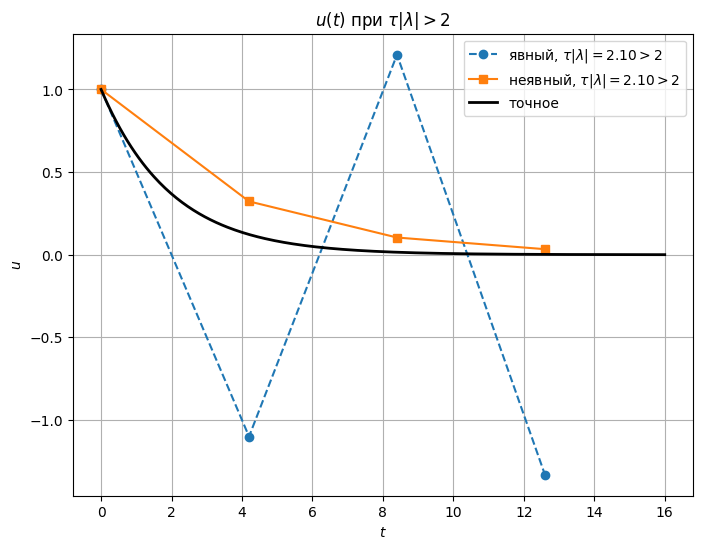

In [163]:
fig, ax = plt.subplots()
ax.plot(tt_b, y_exp_b, "o--", label=rf"явный, $\tau|\lambda|={abs(lam)*dt_big:.2f}>2$")
ax.plot(tt_i_b, y_imp_b, "s-", label=rf"неявный, $\tau|\lambda|={abs(lam)*dt_big:.2f}>2$")
ax.plot(tt_f_big, np.exp(lam * tt_f_big), "k-", lw=2, label="точное")
ax.set_title(r"$u(t)$ при $\tau|\lambda|>2$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.legend()
ax.grid()
plt.show()

lam = -0.5
tt, y = implicit_euler_solve(lam, u0=1.0, T=8 / abs(lam), dt=2.1 / abs(lam))
assert (y > 0).all()


Для $\lambda<0$ знаменатель $1-\tau\lambda = 1+\tau|\lambda|>0$, решение остаётся положительным при $u_0>0$. Явная схема $u_{n+1}=(1+\tau\lambda)u_n$ устойчива при $|\lambda|\tau<2$ (для вещественного $\lambda<0$); при $|\lambda|\tau>2$ возникают знакочередующиеся осцилляции и рост по модулю относительно затухающего точного решения.

Заметим также, что неявный метод Эйлера абсолютно устойчив: для $\operatorname{Re}\lambda<0$ и любого $\tau>0$ имеем $|1/(1-\tau\lambda)|<1$.

# Задача 2

Выпишем схему явно: $\mathbf{u}_{n+1} = \mathbf{u}_n + \tau A\mathbf{u}_n = (I+\tau A)\mathbf{u}_n$.

Аналитическое решение: $\mathbf{u}(t) = e^{tA}\mathbf{u}_0$.

In [164]:
def euler_solve2(a, u0, T, dt):
    """Solve the system du/dt = Au via an explicit Euler scheme."""
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    ndim = a.shape[0]
    y = np.empty((num_steps + 1, ndim))
    y[0] = u0
    for k in range(num_steps):
        y[k + 1] = y[k] + dt * (a @ y[k])
    return tt, y


def mat_exp_solve(a, u0, tt):
    """Решение du/dt = A u с u(0)=u0 в моменты tt; строка u[k] — вектор при t=tt[k]."""
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    tt = np.asarray(tt, dtype=float)
    u = np.empty((len(tt), a.shape[0]))
    for k, tk in enumerate(tt):
        u[k] = expm(tk * a) @ u0
    return u


a = np.array([[-1, 1], [0, -1]], dtype=float)
t2, y2 = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym2 = mat_exp_solve(a, [1, 1], t2)
err2 = np.max(np.abs(y2 - ym2))
print(f"max |y_Euler - y_expm| = {err2:.3e}")


max |y_Euler - y_expm| = 1.920e-02


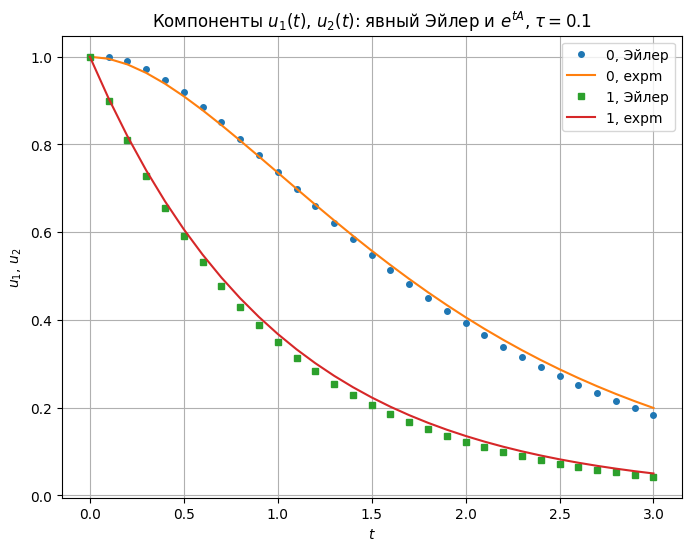

In [165]:
plt.figure()
plt.plot(t2, y2[:, 0], "o", ms=4, label="0, Эйлер")
plt.plot(t2, ym2[:, 0], "-", label="0, expm")
plt.plot(t2, y2[:, 1], "s", ms=4, label="1, Эйлер")
plt.plot(t2, ym2[:, 1], "-", label="1, expm")
plt.legend()
plt.grid()
plt.title(r"Компоненты $u_1(t)$, $u_2(t)$: явный Эйлер и $e^{tA}$, $\tau=0.1$")
plt.xlabel(r"$t$")
plt.ylabel(r"$u_1,\,u_2$")
plt.show()


Сравним: При фиксированном $\tau$ явный Эйлер даёт глобальную ошибку $O(\tau)$ и накопление отклонения от $e^{tA}u_0$ на длинном интервале. Матричная экспонента на той же сетке даёт точку на точном решении в каждом $t_k$, где погрешность только вычислительная от expm.

# Задача 3

In [166]:
A = np.array([[-10.0, 10.0], [32.0, -499.0]])
u0_stiff = np.array([1.0, 0.0])
eig = np.linalg.eigvals(A)
re_abs = np.abs(np.real(eig))
s_stiff = np.max(re_abs) / np.min(re_abs)
print("собственные значения A:", eig)
print(f"число жёсткости s = max|Re(lambda)| / min|Re(lambda)| ≈ {s_stiff:.2f}")
tau_test = 0.01
mu = 1 + tau_test * eig
print(f"при tau={tau_test}: множители явного Эйлера 1+tau*lambda = {mu}")

def implicit_euler_solve2(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    n = a.shape[0]
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, n))
    y[0] = u0
    M = np.eye(n) - dt * a
    for k in range(num_steps):
        y[k + 1] = np.linalg.solve(M, y[k])
    return tt, y


T1 = 1.0
explicit_runs = []
for tau in (4e-3, 4.5e-3):
    t_e, y_e = euler_solve2(A, u0_stiff, T1, tau)
    ym = mat_exp_solve(A, u0_stiff, t_e)
    explicit_runs.append((tau, t_e, y_e, ym))

tau_cmp = 0.01
t_i3, y_i3 = implicit_euler_solve2(A, u0_stiff, T1, tau_cmp)
t_e3, y_e3 = euler_solve2(A, u0_stiff, T1, tau_cmp)
ym3 = mat_exp_solve(A, u0_stiff, t_i3)


собственные значения A: [  -9.34647667 -499.65352333]
число жёсткости s = max|Re(lambda)| / min|Re(lambda)| ≈ 53.46
при tau=0.01: множители явного Эйлера 1+tau*lambda = [ 0.90653523 -3.99653523]


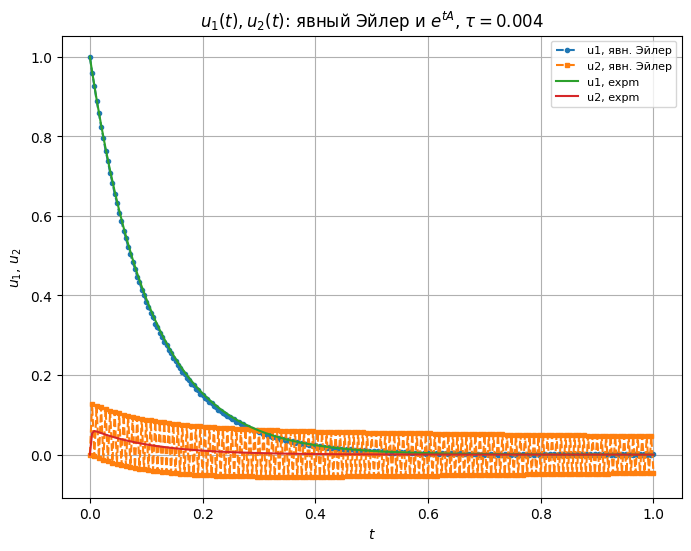

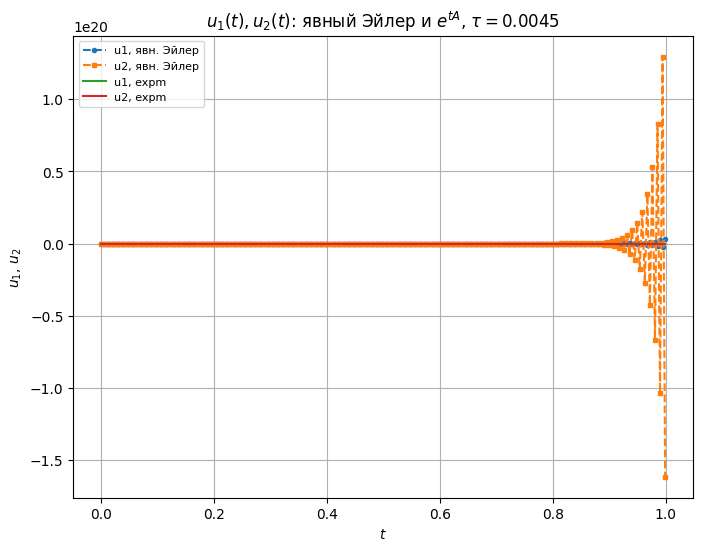

In [167]:
for tau, t_e, y_e, ym in explicit_runs:
    plt.figure()
    plt.plot(t_e, y_e[:, 0], "o--", ms=3, label="u1, явн. Эйлер")
    plt.plot(t_e, y_e[:, 1], "s--", ms=3, label="u2, явн. Эйлер")
    plt.plot(t_e, ym[:, 0], "-", label="u1, expm")
    plt.plot(t_e, ym[:, 1], "-", label="u2, expm")
    plt.title(f"$u_1(t), u_2(t)$: явный Эйлер и $e^{{tA}}$, $\\tau={tau}$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$u_1,\,u_2$")
    plt.legend(fontsize=8)
    plt.grid()
    plt.show()


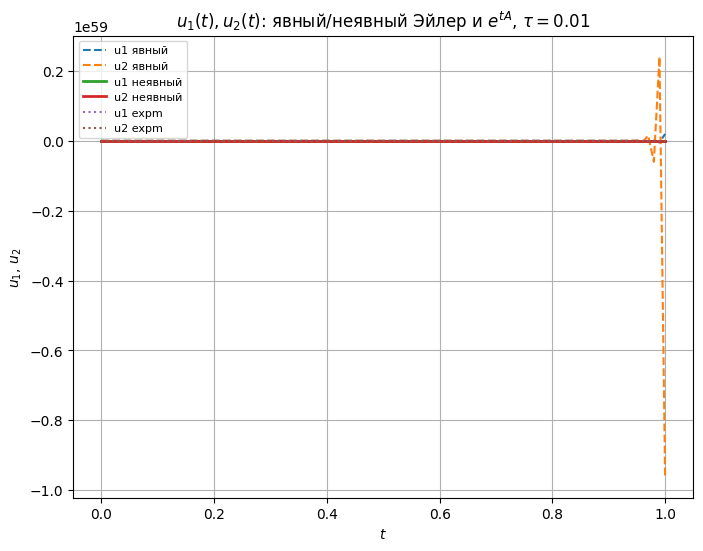

In [168]:
plt.figure()
plt.plot(t_e3, y_e3[:, 0], "--", label="u1 явный")
plt.plot(t_e3, y_e3[:, 1], "--", label="u2 явный")
plt.plot(t_i3, y_i3[:, 0], "-", lw=2, label="u1 неявный")
plt.plot(t_i3, y_i3[:, 1], "-", lw=2, label="u2 неявный")
plt.plot(t_i3, ym3[:, 0], ":", label="u1 expm")
plt.plot(t_i3, ym3[:, 1], ":", label="u2 expm")
plt.title(r"$u_1(t), u_2(t)$: явный/неявный Эйлер и $e^{tA}$, $\tau=0.01$")
plt.xlabel(r"$t$")
plt.ylabel(r"$u_1,\,u_2$")
plt.legend(fontsize=8)
plt.grid()
plt.show()


Сравним: Собственные значения $A$ вещественные отрицательные, сильно различающиеся по модулю, т.е. число жесткости велико. При $\tau=0.01$ для быстрой моды $|1+\tau\lambda|\gg 1$ явный Эйлер неустойчив. При $\tau=4\cdot10^{-3}$ шаг ближе к границе линейной устойчивости; при $4.5\cdot10^{-3}$ явная схема уже даёт растущие осцилляции. Неявный Эйлер остаётся устойчивым при том же $\tau=0.01$ и следует затухающему точному решению.

# Задача 6

Положим $v=u'$:
$$u' = v, \quad v' = -\omega^2 u.$$

Точное решение при $u(0)=u_0$, $v(0)=v_0$:
$$u(t)=u_0\cos\omega t + \frac{v_0}{\omega}\sin\omega t, \quad v(t)=v_0\cos\omega t - \omega u_0\sin\omega t.$$

Тогда для RK2 имеем: $k_1=f(y_n)$, $k_2=f(y_n+\frac{\tau}{2}k_1)$, $y_{n+1}=y_n+\tau k_2$, где $f([u,v]^T)=[v,\,-\omega^2 u]^T$.

Для предиктора-корректора будем делать шаг явным Эйлером $(u^*,v^*)$, затем масштабировать на $\alpha=\sqrt{E_0/E(u^*,v^*)}$ и восстанавливать энергию $E_{n+1}=E_0$ через условие $u_{n+1}=\alpha u^*$, $v_{n+1}=\alpha v^*$.

In [169]:
def energy_harm(u, v, omega):
    return 0.5 * v * v + 0.5 * omega * omega * u * u


def f_harm(state, omega):
    u, v = state
    return np.array([v, -omega**2 * u])


def euler_harm(u0, v0, omega, T, dt):
    n = int(np.round(T / dt))
    dt = T / n
    t = np.linspace(0, T, n + 1)
    y = np.zeros((n + 1, 2))
    y[0] = [u0, v0]
    for k in range(n):
        y[k + 1] = y[k] + dt * f_harm(y[k], omega)
    return t, y


def rk2_harm(u0, v0, omega, T, dt):
    n = int(np.round(T / dt))
    dt = T / n
    t = np.linspace(0, T, n + 1)
    y = np.zeros((n + 1, 2))
    y[0] = [u0, v0]
    for k in range(n):
        k1 = f_harm(y[k], omega)
        k2 = f_harm(y[k] + 0.5 * dt * k1, omega)
        y[k + 1] = y[k] + dt * k2
    return t, y


def pc_harm(u0, v0, omega, T, dt):
    n = int(np.round(T / dt))
    dt = T / n
    t = np.linspace(0, T, n + 1)
    y = np.zeros((n + 1, 2))
    y[0] = [u0, v0]
    E0 = energy_harm(u0, v0, omega)
    for k in range(n):
        u, v = y[k]
        up = u + dt * v
        vp = v - dt * omega**2 * u
        Ep = energy_harm(up, vp, omega)
        if Ep <= 1e-30:
            y[k + 1] = y[k]
        else:
            a = np.sqrt(E0 / Ep)
            y[k + 1] = [a * up, a * vp]
    return t, y


def exact_harm(u0, v0, omega, t):
    u = u0 * np.cos(omega * t) + (v0 / omega) * np.sin(omega * t)
    v = v0 * np.cos(omega * t) - omega * u0 * np.sin(omega * t)
    return u, v


omega = 1.0
u0, v0 = 1.0, 0.0
period = 2 * np.pi / omega
T_long = 10 * period


In [170]:
euler_energy = []
for dt in (0.05, 0.02, 0.01):
    t, y = euler_harm(u0, v0, omega, T_long, dt)
    E = energy_harm(y[:, 0], y[:, 1], omega)
    euler_energy.append((dt, t, E))


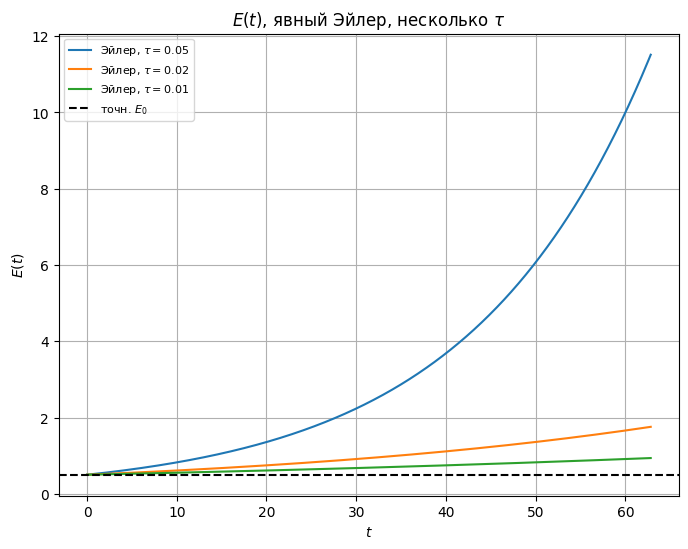

In [171]:
fig, ax = plt.subplots()
for dt, t, E in euler_energy:
    ax.plot(t, E, label=rf"Эйлер, $\tau={dt}$")
ax.axhline(energy_harm(u0, v0, omega), color="k", ls="--", label=r"точн. $E_0$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$E(t)$")
ax.set_title(r"$E(t)$, явный Эйлер, несколько $\tau$")
ax.legend(fontsize=8)
ax.grid()
plt.show()


In [172]:
errors = []
for dt in (0.05, 0.02):
    t, y_e = euler_harm(u0, v0, omega, T_long, dt)
    t, y_r = rk2_harm(u0, v0, omega, T_long, dt)
    ue, ve = exact_harm(u0, v0, omega, t)
    errors.append((dt, t, np.abs(y_e[:, 0] - ue), np.abs(y_r[:, 0] - ue)))


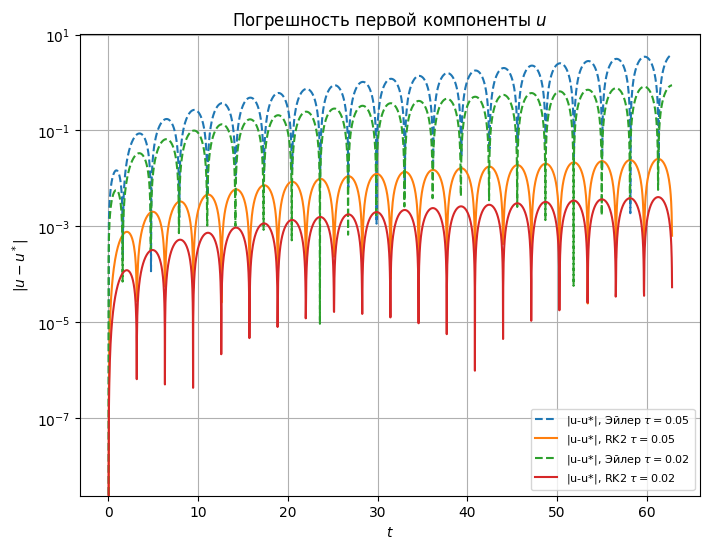

In [173]:
fig, ax = plt.subplots()
for dt, t, err_e, err_r in errors:
    ax.plot(t, err_e, "--", label=rf"|u-u*|, Эйлер $\tau={dt}$")
    ax.plot(t, err_r, "-", label=rf"|u-u*|, RK2 $\tau={dt}$")
ax.set_yscale("log")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$|u-u^*|$")
ax.set_title(r"Погрешность первой компоненты $u$")
ax.legend(fontsize=8)
ax.grid()
plt.show()


In [174]:
dt_comp = 0.05
t_ec, y_e_comp = euler_harm(u0, v0, omega, T_long, dt_comp)
t_rc, y_r_comp = rk2_harm(u0, v0, omega, T_long, dt_comp)
t_pc, y_pc_comp = pc_harm(u0, v0, omega, T_long, dt_comp)
Ee = energy_harm(y_e_comp[:, 0], y_e_comp[:, 1], omega)
Er = energy_harm(y_r_comp[:, 0], y_r_comp[:, 1], omega)
E_pc_comp = energy_harm(y_pc_comp[:, 0], y_pc_comp[:, 1], omega)


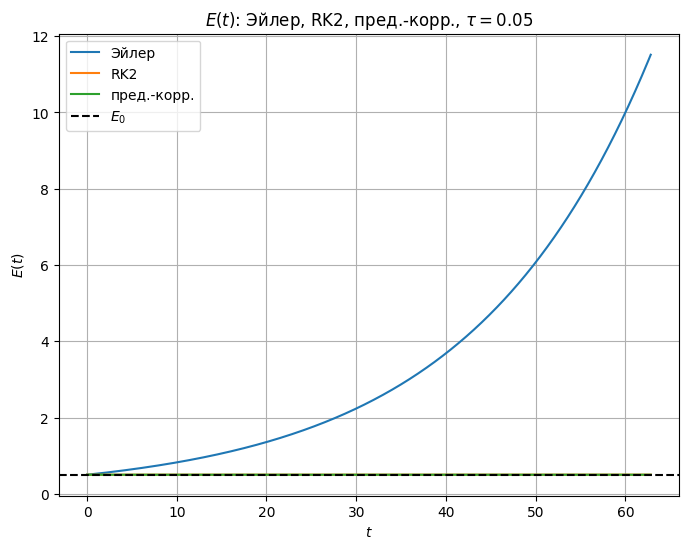

In [175]:
fig, ax = plt.subplots()
ax.plot(t_ec, Ee, label="Эйлер")
ax.plot(t_rc, Er, label="RK2")
ax.plot(t_pc, E_pc_comp, label="пред.-корр.")
ax.axhline(energy_harm(u0, v0, omega), color="k", ls="--", label=r"$E_0$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$E(t)$")
ax.set_title(f"$E(t)$: Эйлер, RK2, пред.-корр., $\\tau={dt_comp}$")
ax.legend()
ax.grid()
plt.show()


In [176]:
n_steps = 20000
dt_small = T_long / n_steps
t_long, y_e_long = euler_harm(u0, v0, omega, T_long, dt_small)
t_long, y_r_long = rk2_harm(u0, v0, omega, T_long, dt_small)
t_long, y_pc_long = pc_harm(u0, v0, omega, T_long, dt_small)
ue_long, ve_long = exact_harm(u0, v0, omega, t_long)
E_e_long = energy_harm(y_e_long[:, 0], y_e_long[:, 1], omega)
E_r_long = energy_harm(y_r_long[:, 0], y_r_long[:, 1], omega)
E_pc = energy_harm(y_pc_long[:, 0], y_pc_long[:, 1], omega)


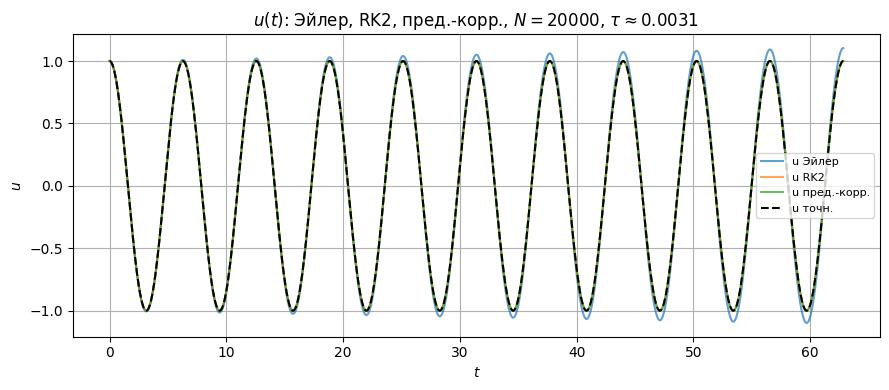

In [177]:
plt.figure(figsize=(9, 4))
plt.plot(t_long, y_e_long[:, 0], alpha=0.7, label="u Эйлер")
plt.plot(t_long, y_r_long[:, 0], alpha=0.7, label="u RK2")
plt.plot(t_long, y_pc_long[:, 0], alpha=0.7, label="u пред.-корр.")
plt.plot(t_long, ue_long, "k--", lw=1.5, label="u точн.")
plt.xlabel(r"$t$")
plt.ylabel(r"$u$")
plt.title(f"$u(t)$: Эйлер, RK2, пред.-корр., $N={n_steps}$, $\\tau\\approx {dt_small:.4f}$")
plt.legend(fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()


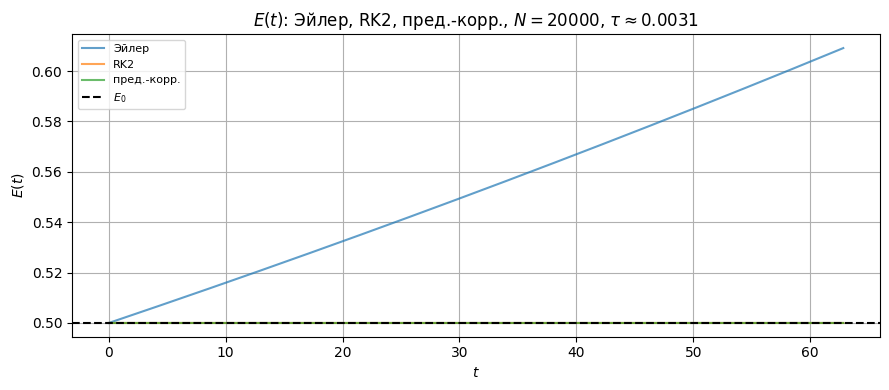

In [178]:
plt.figure(figsize=(9, 4))
plt.plot(t_long, E_e_long, alpha=0.7, label="Эйлер")
plt.plot(t_long, E_r_long, alpha=0.7, label="RK2")
plt.plot(t_long, E_pc, alpha=0.7, label="пред.-корр.")
plt.axhline(energy_harm(u0, v0, omega), color="k", ls="--", label=r"$E_0$")
plt.xlabel(r"$t$")
plt.ylabel(r"$E(t)$")
plt.title(f"$E(t)$: Эйлер, RK2, пред.-корр., $N={n_steps}$, $\\tau\\approx {dt_small:.4f}$")
plt.legend(fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()

Вывод: Явный Эйлер для гамильтоновой системы не сохраняет энергию. RK2 даёт квадратичную локальную точность и заметно меньше искажает энергию, но при очень большом числе шагов накапливается ошибка. Предиктор–корректор с проекцией на уровень $E=E_0$ жёстко фиксирует энергию (как изначально и планировалось)